In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import pathlib

# from src.diffusion_mnist import CondDiffuser
from src.diffusion_mnist_normalize import CondDiffuser
from src.simple_unet import CondSimpleUnet


## 条件付き拡散モデルの学習

In [2]:
DATASET_CONFIG = {
    "MNIST": {
        "channels": 1,
        "image_size": 28,
        "image_range": "-1,1",
    },
    "FashionMNIST": {
        "channels": 1,
        "image_size": 28,
        "image_range": "-1,1",
    },
    "CIFAR10": {
        "channels": 3,
        "image_size": 32,
        "image_range": "-1,1",
    },
}

dataset_name = "CIFAR10"  # "MNIST", "FashionMNIST", "CIFAR10"

In [ ]:
config = DATASET_CONFIG[dataset_name]

# ハイパーパラメータ
img_size = config["image_size"]
batch_size = 128
num_timesteps = 500
# num_timesteps = 1000
num_labels = 10
epochs = 10
# epochs = 2  # デバック用
lr = 5e-4
in_ch = config["channels"]
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [4]:
def get_transform(dataset_name, image_range="-1,1"):
    if dataset_name in ["MNIST", "FashionMNIST"]:
        mean = (0.5,)
        std = (0.5,)
    elif dataset_name == "CIFAR10":
        mean = (0.5, 0.5, 0.5)
        std = (0.5, 0.5, 0.5)
    else:
        raise ValueError(dataset_name)

    if image_range == "0,1":
        return transforms.Compose([
            transforms.ToTensor(),
        ])

    elif image_range == "-1,1":
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    else:
        raise ValueError(image_range)


def get_dataset(dataset_name, root="./data", train=True, image_range="-1,1"):
    # データの前処理のためのtransformを取得します。
    transform = get_transform(dataset_name, image_range)

    if dataset_name == "MNIST":
        return torchvision.datasets.MNIST(
            root=root / "data_mnist", train=train, download=True, transform=transform
        )

    elif dataset_name == "FashionMNIST":
        return torchvision.datasets.FashionMNIST(
            root=root / "data_fashion_mnist", train=train, download=True, transform=transform
        )

    elif dataset_name == "CIFAR10":
        return torchvision.datasets.CIFAR10(
            root=root / "data_cifar10", train=train, download=True, transform=transform
        )

    else:
        raise ValueError(dataset_name)

In [5]:
# データセットの準備
dataset = get_dataset(dataset_name, root=pathlib.Path("."), train=True, image_range=config["image_range"])
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

c:\Users\Masahiko\anaconda3\envs\scipy\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:
model_unet = CondSimpleUnet(in_ch=3, num_labels=num_labels)
diffuser_mnist = CondDiffuser(model=model_unet,num_timesteps=num_timesteps, beta_schedule_type='cosine',gamma=2.0, device=device)
optimizer = Adam(diffuser_mnist.unet_model.parameters(), lr=lr)

In [7]:
def show_images(images, rows=2, cols=10):
    fig = plt.figure(figsize=(cols, rows))
    i = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.axis('off')
            i += 1
    plt.show()


def show_images_cond(images, labels, rows=2, cols=10):
    fig, ax = plt.subplots(rows, cols, figsize=(10, 2.5), sharey=True)
    i = 0
    for r in range(rows):
        for c in range(cols):
            ax[r, c].imshow(images[i], cmap='gray')
            ax[r, c].set_title(f"{labels[i]}", ha="center", fontsize=15)
            ax[r, c].axis('off')
            i += 1
    plt.tight_layout()
    plt.show()

100%|██████████| 50/50 [00:13<00:00,  3.84it/s]


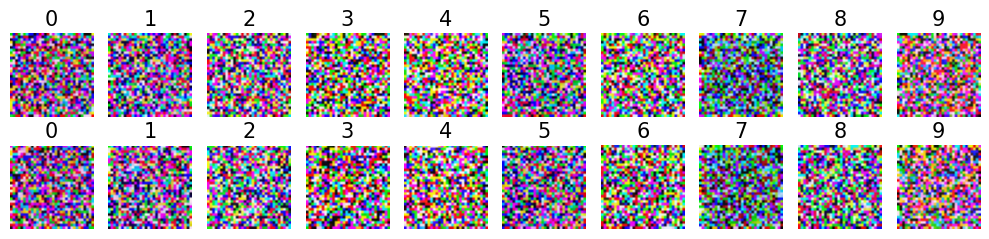

100%|██████████| 391/391 [14:11<00:00,  2.18s/it]


Epoch: 0 | Loss:0.3208104896042353


100%|██████████| 50/50 [00:13<00:00,  3.69it/s]


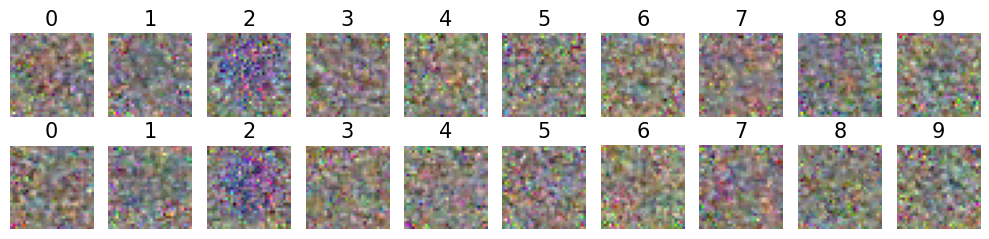

100%|██████████| 391/391 [14:22<00:00,  2.21s/it]


Epoch: 1 | Loss:0.13109123891653002


100%|██████████| 50/50 [00:13<00:00,  3.80it/s]


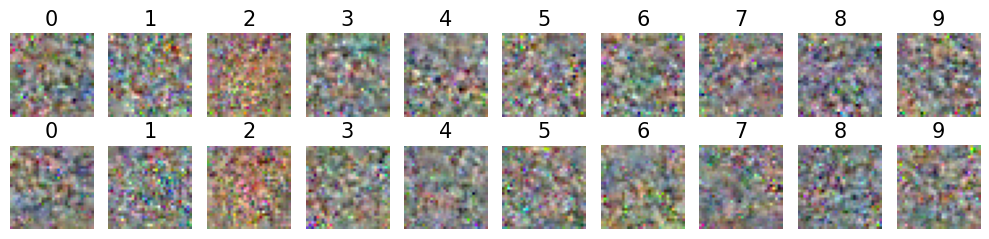

100%|██████████| 391/391 [14:29<00:00,  2.22s/it]


Epoch: 2 | Loss:0.11154193229153943


100%|██████████| 50/50 [00:13<00:00,  3.80it/s]


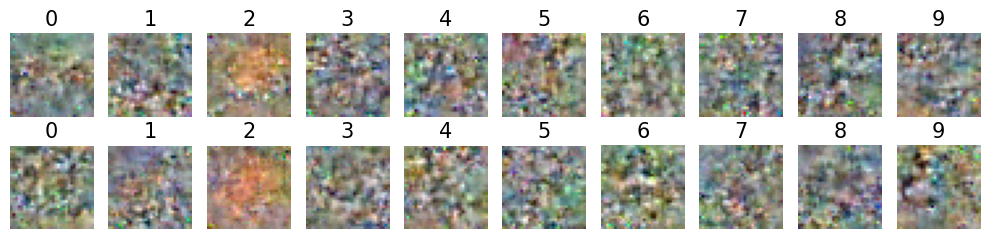

100%|██████████| 391/391 [14:30<00:00,  2.23s/it]


Epoch: 3 | Loss:0.10403430839176372


100%|██████████| 50/50 [00:12<00:00,  3.86it/s]


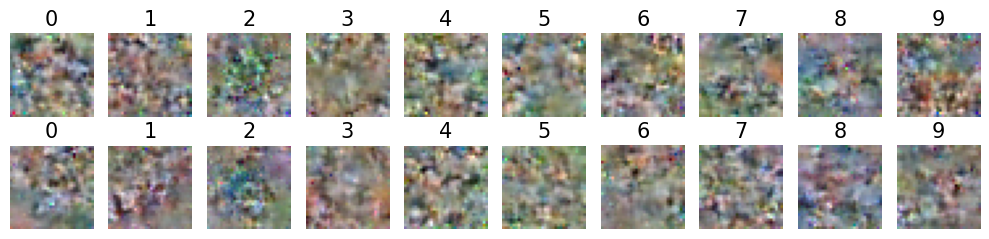

100%|██████████| 391/391 [14:34<00:00,  2.24s/it]


Epoch: 4 | Loss:0.09835514085143424


100%|██████████| 50/50 [00:13<00:00,  3.77it/s]


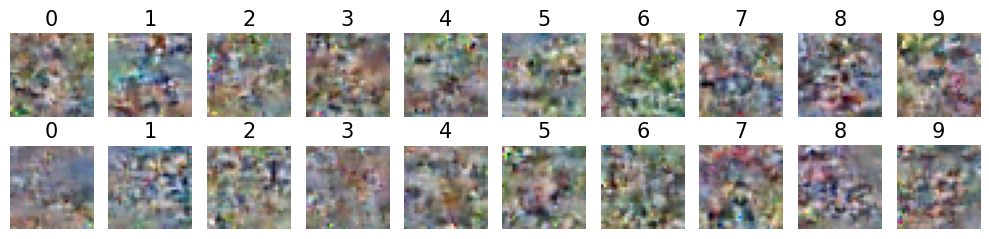

100%|██████████| 391/391 [14:36<00:00,  2.24s/it]


Epoch: 5 | Loss:0.09253407967136339


100%|██████████| 50/50 [00:13<00:00,  3.62it/s]


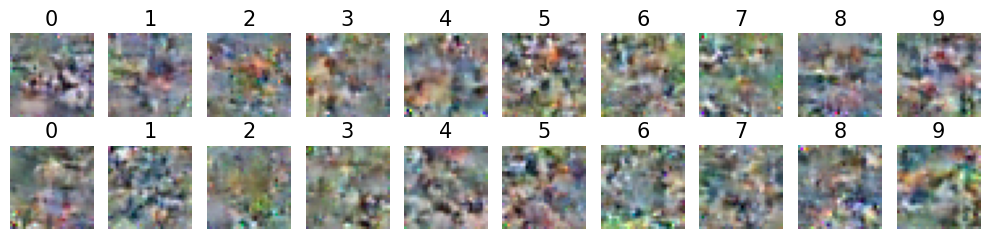

100%|██████████| 391/391 [14:31<00:00,  2.23s/it]


Epoch: 6 | Loss:0.0905239763848312


100%|██████████| 50/50 [00:13<00:00,  3.78it/s]


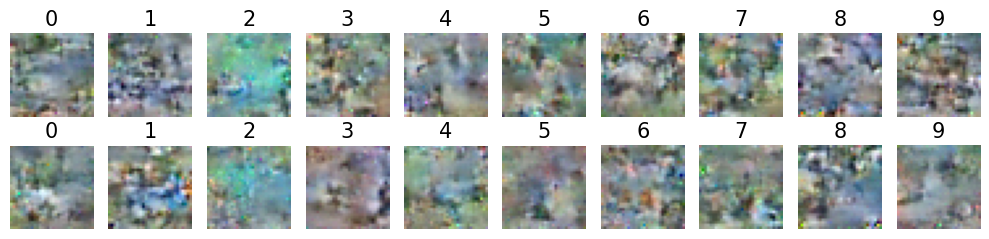

100%|██████████| 391/391 [14:23<00:00,  2.21s/it]


Epoch: 7 | Loss:0.08675989417163917


100%|██████████| 50/50 [00:12<00:00,  4.15it/s]


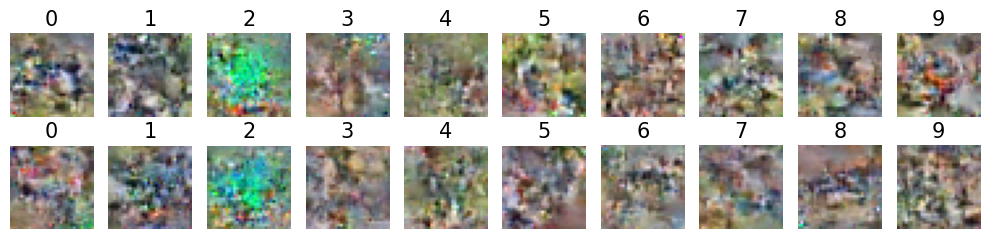

  9%|▉         | 37/391 [01:14<11:54,  2.02s/it]


KeyboardInterrupt: 

In [8]:
losses = []
for epoch in range(epochs):
    loss_sum = 0
    cnt = 0

    labels_test = torch.arange(0, 10).repeat(2)
    images = diffuser_mnist.ddim_sampling(x_shape=(20, 3, 32, 32), labels=labels_test)
    show_images_cond(images, labels_test)

    for imeges, labels in tqdm(dataloader):
        optimizer.zero_grad()
        x = imeges.to(device)
        labels.to(device)
        timestep= torch.randint(1, num_timesteps+1, (len(x),), device=device)

        # 分類器なしガイダンスによる学習
        # 10%の確率で条件なしで学習
        if np.random.random() < 0.1:
            labels = None

        x_noisy, noise = diffuser_mnist.add_noise(x, timestep)
        noise_pred = diffuser_mnist.unet_model(x_noisy, timestep, labels)
        loss = F.mse_loss(noise, noise_pred)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1

    
    loss_avg = loss_sum /cnt
    losses.append(loss_avg)
    print(f"Epoch: {epoch} | Loss:{loss_avg}")

In [ ]:
# plot losses
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 条件付き拡散モデルによる生成

In [ ]:
# generate samples
labels = torch.arange(0, 10).repeat(2)
images = diffuser_mnist.ddpm_sampling(x_shape=(20, 3, 32, 32), labels=labels)
show_images_cond(images, labels)

In [ ]:
model_path = "model_cifar10_20260503.pth"
torch.save(diffuser_mnist.unet_model.state_dict(), model_path )

## 学習済みモデルでの動作検証

In [ ]:
model_path = model_path
model_unet = CondSimpleUnet(in_ch=3,num_labels=num_labels)
model_unet.load_state_dict(torch.load(model_path))
diffuser_mnist = CondDiffuser(model=model_unet,num_timesteps=500, device=device)

In [ ]:
# generate samples
labels = torch.arange(0, 10).repeat(2)
images = diffuser_mnist.ddim_sampling(x_shape=(20, 3, 32, 32), labels=labels)
show_images_cond(images, labels)

In [ ]:
# generate samples
# labels = torch.arange(0, 10).repeat(2)
# images = diffuser_mnist.ddpm_sampling(x_shape=(20, 3, 32, 32), labels=labels)
# show_images_cond(images, labels)